In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
import trimesh



In [54]:
def get_vertices_texture_mapping(obj_path):
    """
    获取OBJ模型中每个顶点在纹理上的坐标
    
    参数:
    obj_path: OBJ文件路径
    
    返回:
    vertex_to_texture: 字典，键为顶点索引，值为该顶点在纹理上的坐标列表(可能有多个)
    texture_to_vertex: 字典，键为纹理坐标索引，值为使用该纹理坐标的顶点索引列表
    vertices: 顶点坐标数组
    vts: 纹理坐标数组
    faces: 面信息列表
    """
    print(f"从OBJ文件读取顶点-纹理映射关系: {obj_path}")
    
    # 读取OBJ文件
    with open(obj_path, 'r') as f:
        lines = f.readlines()
    
    # 解析顶点和纹理坐标
    vertices = []
    vts = []
    faces = []
    
    for line in lines:
        line = line.strip()
        if line.startswith('v '):
            # 解析顶点坐标
            parts = line.split()
            if len(parts) >= 4:
                vertices.append([float(parts[1]), float(parts[2]), float(parts[3])])
        elif line.startswith('vt '):
            # 解析纹理坐标
            parts = line.split()
            if len(parts) >= 3:
                vts.append([float(parts[1]), float(parts[2])])
        elif line.startswith('f '):
            # 解析面信息
            parts = line.split()[1:]
            face_vertices = []
            face_vts = []
            
            for part in parts:
                indices = part.split('/')
                if len(indices) >= 2 and indices[0] and indices[1]:
                    # OBJ索引从1开始，所以要减1
                    v_idx = int(indices[0]) - 1
                    vt_idx = int(indices[1]) - 1
                    face_vertices.append(v_idx)
                    face_vts.append(vt_idx)
            
            if len(face_vertices) >= 3:
                faces.append((face_vertices, face_vts))
    
    # 转换为numpy数组
    vertices = np.array(vertices)
    vts = np.array(vts)
    
    print(f"解析结果:")
    print(f"  顶点数量: {len(vertices)}")
    print(f"  纹理坐标数量: {len(vts)}")
    print(f"  面数量: {len(faces)}")
    
    # 创建顶点到纹理坐标的映射
    vertex_to_texture = {}  # 键: 顶点索引, 值: 该顶点使用的纹理坐标列表
    texture_to_vertex = {}  # 键: 纹理坐标索引, 值: 使用该纹理坐标的顶点列表
    
    # 遍历所有面，建立映射关系
    for face_vertices, face_vts in faces:
        for v_idx, vt_idx in zip(face_vertices, face_vts):
            # 添加到顶点->纹理映射
            if v_idx not in vertex_to_texture:
                vertex_to_texture[v_idx] = []
            if vt_idx not in vertex_to_texture[v_idx]:
                vertex_to_texture[v_idx].append(vt_idx)
            
            # 添加到纹理->顶点映射
            if vt_idx not in texture_to_vertex:
                texture_to_vertex[vt_idx] = []
            if v_idx not in texture_to_vertex[vt_idx]:
                texture_to_vertex[vt_idx].append(v_idx)
    
    # 统计映射情况
    vertices_with_texture = len(vertex_to_texture)
    avg_textures_per_vertex = sum(len(textures) for textures in vertex_to_texture.values()) / max(1, vertices_with_texture)
    
    print(f"映射统计:")
    print(f"  有纹理映射的顶点数量: {vertices_with_texture}/{len(vertices)} ({vertices_with_texture/len(vertices)*100:.1f}%)")
    print(f"  每个顶点平均使用的纹理坐标数量: {avg_textures_per_vertex:.2f}")
    
    return vertex_to_texture, texture_to_vertex, vertices, vts, faces

def visualize_vertex_texture_mapping(obj_path):
    """
    可视化OBJ模型中顶点与纹理之间的映射关系
    
    参数:
    obj_path: OBJ文件路径
    """
    # 获取映射关系
    vertex_to_texture, texture_to_vertex, vertices, vts, faces = get_vertices_texture_mapping(obj_path)
    
    # 获取贴图
    texture = None
    obj_dir = os.path.dirname(obj_path)
    tex_name = os.path.splitext(os.path.basename(obj_path))[0] + '_TEX.png'
    tex_path = os.path.join(obj_dir, tex_name)
    
    if os.path.exists(tex_path):
        print(f"从文件加载贴图: {tex_path}")
        texture = np.array(Image.open(tex_path))
    else:
        print("找不到贴图文件，创建棋盘格贴图")
        # 创建一个简单的棋盘格贴图
        texture = np.zeros((512, 512, 3), dtype=np.uint8)
        for i in range(8):
            for j in range(8):
                if (i + j) % 2 == 0:
                    texture[i*64:(i+1)*64, j*64:(j+1)*64] = [200, 200, 200]
                else:
                    texture[i*64:(i+1)*64, j*64:(j+1)*64] = [100, 100, 100]
    
    # 纹理高度和宽度
    tex_height, tex_width = texture.shape[:2]
    
    # 创建图形
    fig = plt.figure(figsize=(18, 12))
    
    # 1. 显示3D模型和纹理图
    ax1 = fig.add_subplot(231, projection='3d')
    ax1.set_title("3D模型顶点")
    
    # 绘制所有顶点
    ax1.scatter(vertices[:, 0], vertices[:, 1], vertices[:, 2], 
                c='gray', s=2, alpha=0.3, label='所有顶点')
    
    # 绘制有纹理映射的顶点
    vertices_with_tex = np.array([vertices[idx] for idx in vertex_to_texture.keys()])
    if len(vertices_with_tex) > 0:
        ax1.scatter(vertices_with_tex[:, 0], vertices_with_tex[:, 1], vertices_with_tex[:, 2], 
                    c='red', s=10, alpha=0.8, label='有纹理映射的顶点')
    
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.legend()
    
    # 2. 显示纹理图
    ax2 = fig.add_subplot(232)
    ax2.set_title("纹理图")
    ax2.imshow(texture)
    
    # 在纹理图上标记纹理坐标点
    for vt_idx, vt in enumerate(vts):
        # 转换为图像坐标
        x = vt[0] * tex_width
        y = (1 - vt[1]) * tex_height  # 翻转y坐标
        
        # 如果这个纹理坐标被使用了，用红色标记
        if vt_idx in texture_to_vertex:
            ax2.scatter(x, y, c='red', s=5, alpha=0.7)
        else:
            # 否则用灰色标记
            ax2.scatter(x, y, c='gray', s=2, alpha=0.3)
    
    ax2.axis('off')
    
    # 3. 显示顶点-纹理映射关系
    ax3 = fig.add_subplot(233)
    ax3.set_title("顶点-纹理映射分布")
    
    # 统计每个顶点使用的纹理坐标数量
    textures_per_vertex = [len(textures) for textures in vertex_to_texture.values()]
    ax3.hist(textures_per_vertex, bins=range(1, max(textures_per_vertex) + 2), 
             alpha=0.7, color='blue', edgecolor='black')
    ax3.set_xlabel('每个顶点使用的纹理坐标数量')
    ax3.set_ylabel('顶点数量')
    ax3.grid(True, alpha=0.3)
    
    # 4. 选择几个示例顶点，展示它们在3D模型和纹理上的位置
    ax4 = fig.add_subplot(234, projection='3d')
    ax4.set_title("示例顶点在3D模型上的位置")
    
    # 5. 这些示例顶点在纹理上的位置
    ax5 = fig.add_subplot(235)
    ax5.set_title("示例顶点在纹理上的位置")
    ax5.imshow(texture)
    
    # 选择最多5个有纹理映射的顶点作为示例
    sample_vertices = list(vertex_to_texture.keys())
    if len(sample_vertices) > 5:
        # 随机选择5个顶点
        np.random.seed(42)  # 设置随机种子以保证结果可重复
        sample_vertices = np.random.choice(sample_vertices, 5, replace=False)
    
    # 为示例顶点分配不同颜色
    colors = ['red', 'green', 'blue', 'purple', 'orange']
    
    for i, v_idx in enumerate(sample_vertices):
        color = colors[i % len(colors)]
        v_pos = vertices[v_idx]
        
        # 在3D模型上标记该顶点
        ax4.scatter([v_pos[0]], [v_pos[1]], [v_pos[2]], 
                    c=color, s=100, alpha=0.8, label=f'顶点 {v_idx}')
        
        # 在纹理上标记该顶点的所有纹理坐标
        for vt_idx in vertex_to_texture[v_idx]:
            vt = vts[vt_idx]
            x = vt[0] * tex_width
            y = (1 - vt[1]) * tex_height
            ax5.scatter(x, y, c=color, s=100, alpha=0.8, marker='*')
            
            # 添加标签
            ax5.annotate(f'v{v_idx}', (x, y), xytext=(5, 5), 
                         textcoords='offset points', color=color, fontsize=8)
    
    ax4.set_xlabel('X')
    ax4.set_ylabel('Y')
    ax4.set_zlabel('Z')
    ax4.legend()
    ax5.axis('off')
    
    # 6. 附加信息
    ax6 = fig.add_subplot(236)
    ax6.axis('off')
    info_text = (
        f"模型信息:\n"
        f"- 顶点总数: {len(vertices)}\n"
        f"- 纹理坐标总数: {len(vts)}\n"
        f"- 面总数: {len(faces)}\n\n"
        f"映射统计:\n"
        f"- 有纹理映射的顶点: {len(vertex_to_texture)}/{len(vertices)} "
        f"({len(vertex_to_texture)/len(vertices)*100:.1f}%)\n"
        f"- 被使用的纹理坐标: {len(texture_to_vertex)}/{len(vts)} "
        f"({len(texture_to_vertex)/len(vts)*100:.1f}%)\n"
        f"- 每个顶点平均使用的纹理坐标数: "
        f"{sum(len(t) for t in vertex_to_texture.values())/max(1, len(vertex_to_texture)):.2f}\n"
        f"- 每个纹理坐标平均映射到的顶点数: "
        f"{sum(len(v) for v in texture_to_vertex.values())/max(1, len(texture_to_vertex)):.2f}"
    )
    ax6.text(0.05, 0.95, info_text, transform=ax6.transAxes, 
             fontsize=10, verticalalignment='top', family='monospace')
    
    plt.tight_layout()
    plt.savefig('vertex_texture_mapping.png', dpi=300)
    print("已保存顶点-纹理映射可视化到： vertex_texture_mapping.png")
    plt.show()

def texture_to_3d_coordinates_via_vertices(obj_path, output_path=None):
    """
    通过顶点纹理映射，将纹理图上的每个像素映射到3D模型坐标
    
    参数:
    obj_path: OBJ文件路径
    output_path: 输出结果的路径，如果为None则不保存
    
    返回：
    texture_3d_map: 形状为(height, width, 3)的numpy数组，存储每个纹理像素对应的3D坐标
    mapped_mask: 形状为(height, width)的布尔数组，标记哪些像素已经被映射
    """
    print(f"基于顶点纹理映射计算纹理到3D映射: {obj_path}")
    
    # 获取顶点纹理映射关系
    vertex_to_texture, texture_to_vertex, vertices, vts, faces = get_vertices_texture_mapping(obj_path)
    
    # 获取贴图
    texture = None
    obj_dir = os.path.dirname(obj_path)
    tex_name = os.path.splitext(os.path.basename(obj_path))[0] + '_TEX.png'
    tex_path = os.path.join(obj_dir, tex_name)
    
    if os.path.exists(tex_path):
        print(f"从文件加载贴图: {tex_path}")
        texture = np.array(Image.open(tex_path))
    else:
        print("找不到贴图文件，创建棋盘格贴图")
        # 创建一个简单的棋盘格贴图
        texture = np.zeros((512, 512, 3), dtype=np.uint8)
        for i in range(8):
            for j in range(8):
                if (i + j) % 2 == 0:
                    texture[i*64:(i+1)*64, j*64:(j+1)*64] = [200, 200, 200]
                else:
                    texture[i*64:(i+1)*64, j*64:(j+1)*64] = [100, 100, 100]
    
    # 纹理高度和宽度
    tex_height, tex_width = texture.shape[:2]
    
    # 创建一个与纹理图同样大小的3D坐标映射数组
    texture_3d_map = np.zeros((tex_height, tex_width, 3), dtype=np.float32)
    # 创建一个掩码，标记哪些像素已经被映射
    mapped_mask = np.zeros((tex_height, tex_width), dtype=bool)
    
    # 定义一个函数计算点在三角形内的重心坐标
    def barycentric_coordinates(p, a, b, c):
        """
        计算点p在三角形abc中的重心坐标
        
        参数:
        p, a, b, c: 2D点坐标
        
        返回：
        (u, v, w): 重心坐标，如果点在三角形外，则某些坐标可能为负
        """
        v0 = b - a
        v1 = c - a
        v2 = p - a
        
        # 计算点积
        d00 = np.dot(v0, v0)
        d01 = np.dot(v0, v1)
        d11 = np.dot(v1, v1)
        d20 = np.dot(v2, v0)
        d21 = np.dot(v2, v1)
        
        # 计算重心坐标
        denom = d00 * d11 - d01 * d01
        if abs(denom) < 1e-10:
            return (-1, -1, -1)  # 退化三角形
        
        v = (d11 * d20 - d01 * d21) / denom
        w = (d00 * d21 - d01 * d20) / denom
        u = 1.0 - v - w
        
        return (u, v, w)
    
    # 定义一个函数判断点是否在三角形内
    def point_in_triangle(p, a, b, c):
        """
        判断点p是否在三角形abc内部
        
        参数:
        p, a, b, c: 2D点坐标
        
        返回:
        bool: 如果点在三角形内（包括边界）则为True
        """
        u, v, w = barycentric_coordinates(p, a, b, c)
        # 允许一点点数值误差
        epsilon = 1e-5
        return (u >= -epsilon) and (v >= -epsilon) and (w >= -epsilon) and (abs(u + v + w - 1.0) < epsilon)
    
    print("开始计算纹理到3D映射...")
    
    # 对每个三角形面进行处理
    for face_idx, (face_vertices, face_vts) in enumerate(faces):
        if len(face_vertices) < 3 or len(face_vts) < 3:
            continue
        
        # 获取面的顶点和纹理坐标
        v_indices = face_vertices[:3]  # 只处理前三个点（如果是四边形，拆分为三角形）
        vt_indices = face_vts[:3]
        
        # 获取三角形的3D顶点
        tri_vertices = vertices[v_indices]
        
        # 获取三角形的纹理坐标并转换为图像坐标
        tri_vts = vts[vt_indices]
        tri_vts_img = np.copy(tri_vts)
        tri_vts_img[:, 0] *= tex_width
        tri_vts_img[:, 1] = (1 - tri_vts_img[:, 1]) * tex_height  # 翻转y坐标
        
        # 计算三角形的包围盒
        min_x = max(0, int(np.floor(np.min(tri_vts_img[:, 0]))))
        max_x = min(tex_width - 1, int(np.ceil(np.max(tri_vts_img[:, 0]))))
        min_y = max(0, int(np.floor(np.min(tri_vts_img[:, 1]))))
        max_y = min(tex_height - 1, int(np.ceil(np.max(tri_vts_img[:, 1]))))
        
        # 对包围盒内的每个像素进行处理
        for y in range(min_y, max_y + 1):
            for x in range(min_x, max_x + 1):
                # 如果这个像素已经被映射，跳过
                if mapped_mask[y, x]:
                    continue
                
                # 检查像素是否在三角形内
                pixel_pos = np.array([x, y])
                if point_in_triangle(pixel_pos, tri_vts_img[0], tri_vts_img[1], tri_vts_img[2]):
                    # 计算重心坐标
                    u, v, w = barycentric_coordinates(pixel_pos, tri_vts_img[0], tri_vts_img[1], tri_vts_img[2])
                    
                    # 使用重心坐标插值计算3D坐标
                    pos_3d = u * tri_vertices[0] + v * tri_vertices[1] + w * tri_vertices[2]
                    
                    # 存储3D坐标
                    texture_3d_map[y, x] = pos_3d
                    mapped_mask[y, x] = True
        
        # 每处理100个面打印一次进度
        if (face_idx + 1) % 100 == 0 or face_idx == len(faces) - 1:
            print(f"处理进度: {face_idx + 1}/{len(faces)} 面 ({(face_idx + 1) / len(faces) * 100:.1f}%)")
    
    # 计算映射覆盖率
    coverage = np.sum(mapped_mask) / (tex_height * tex_width) * 100
    print(f"纹理映射覆盖率: {coverage:.2f}%")
    
    # 可视化结果
    # 创建一个RGB图像，显示3D坐标的映射
    # 将3D坐标归一化到[0,1]范围用于可视化
    min_coords = np.min(vertices, axis=0)
    max_coords = np.max(vertices, axis=0)
    range_coords = max_coords - min_coords
    
    # 避免除以零
    range_coords[range_coords < 1e-10] = 1.0
    
    # 创建归一化的3D坐标可视化
    normalized_map = np.zeros_like(texture_3d_map)
    normalized_map[mapped_mask] = (texture_3d_map[mapped_mask] - min_coords) / range_coords
    
    # 创建可视化图像
    plt.figure(figsize=(15, 10))
    
    # 显示原始纹理
    plt.subplot(2, 2, 1)
    plt.imshow(texture)
    plt.title("原始纹理")
    plt.axis('off')
    
    # 显示映射掩码
    plt.subplot(2, 2, 2)
    plt.imshow(mapped_mask, cmap='gray')
    plt.title(f"映射覆盖 ({coverage:.2f}%)")
    plt.axis('off')
    
    # 显示X坐标映射
    plt.subplot(2, 2, 3)
    plt.imshow(normalized_map[:, :, 0], cmap='jet')
    plt.title("X坐标映射")
    plt.axis('off')
    plt.colorbar()
    
    # 显示Y坐标映射
    plt.subplot(2, 2, 4)
    plt.imshow(normalized_map[:, :, 1], cmap='jet')
    plt.title("Y坐标映射")
    plt.axis('off')
    plt.colorbar()
    
    plt.tight_layout()
    
    # 保存结果
    if output_path:
        plt.savefig(output_path, dpi=300)
        print(f"已保存可视化结果到： {output_path}")
        
        # 保存3D坐标映射为numpy数组
        np_output_path = os.path.splitext(output_path)[0] + "_3d_map.npy"
        np.save(np_output_path, texture_3d_map)
        print(f"已保存3D坐标映射数据到: {np_output_path}")
        
        # 保存掩码
        mask_output_path = os.path.splitext(output_path)[0] + "_mask.npy"
        np.save(mask_output_path, mapped_mask)
        print(f"已保存映射掩码到: {mask_output_path}")
    
    plt.show()
    
    return texture_3d_map, mapped_mask


从OBJ文件读取顶点-纹理映射关系: /home/arno/Projects/Pint3D/print_ngp/Mesh2Volume/ExampleMesh/Minecraft_Grass_Block_OBJ/Grass_Block.obj
解析结果:
  顶点数量: 8
  纹理坐标数量: 14
  面数量: 6
映射统计:
  有纹理映射的顶点数量: 8/8 (100.0%)
  每个顶点平均使用的纹理坐标数量: 1.75
从文件加载贴图: /home/arno/Projects/Pint3D/print_ngp/Mesh2Volume/ExampleMesh/Minecraft_Grass_Block_OBJ/Grass_Block_TEX.png


/tmp/ipykernel_2492002/1796261401.py:246: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) Ubuntu.
  plt.tight_layout()
/tmp/ipykernel_2492002/1796261401.py:246: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) Ubuntu.
  plt.tight_layout()
/tmp/ipykernel_2492002/1796261401.py:246: UserWarning: Glyph 39030 (\N{CJK UNIFIED IDEOGRAPH-9876}) missing from font(s) Ubuntu.
  plt.tight_layout()
/tmp/ipykernel_2492002/1796261401.py:246: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) Ubuntu.
  plt.tight_layout()
/tmp/ipykernel_2492002/1796261401.py:246: UserWarning: Glyph 25152 (\N{CJK UNIFIED IDEOGRAPH-6240}) missing from font(s) Ubuntu.
  plt.tight_layout()
/tmp/ipykernel_2492002/1796261401.py:246: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from font(s) Ubuntu.
  plt.tight_layout()
/tmp/ipykernel_2492002/1796261401.py:246: UserWarning: Glyph 32441 (\N{CJK UNIFIED IDEOGRAPH-7EB9}) 

已保存顶点-纹理映射可视化到： vertex_texture_mapping.png


/home/arno/conda/envs/print3DNerfCUDA124/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) Ubuntu.
  fig.canvas.print_figure(bytes_io, **kw)
/home/arno/conda/envs/print3DNerfCUDA124/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) Ubuntu.
  fig.canvas.print_figure(bytes_io, **kw)
/home/arno/conda/envs/print3DNerfCUDA124/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39030 (\N{CJK UNIFIED IDEOGRAPH-9876}) missing from font(s) Ubuntu.
  fig.canvas.print_figure(bytes_io, **kw)
/home/arno/conda/envs/print3DNerfCUDA124/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) Ubuntu.
  fig.canvas.print_figure(bytes_io, **kw)
/home/arno/conda/envs/print3DNerfCUDA124/lib/python3.11/site-packages/IPytho

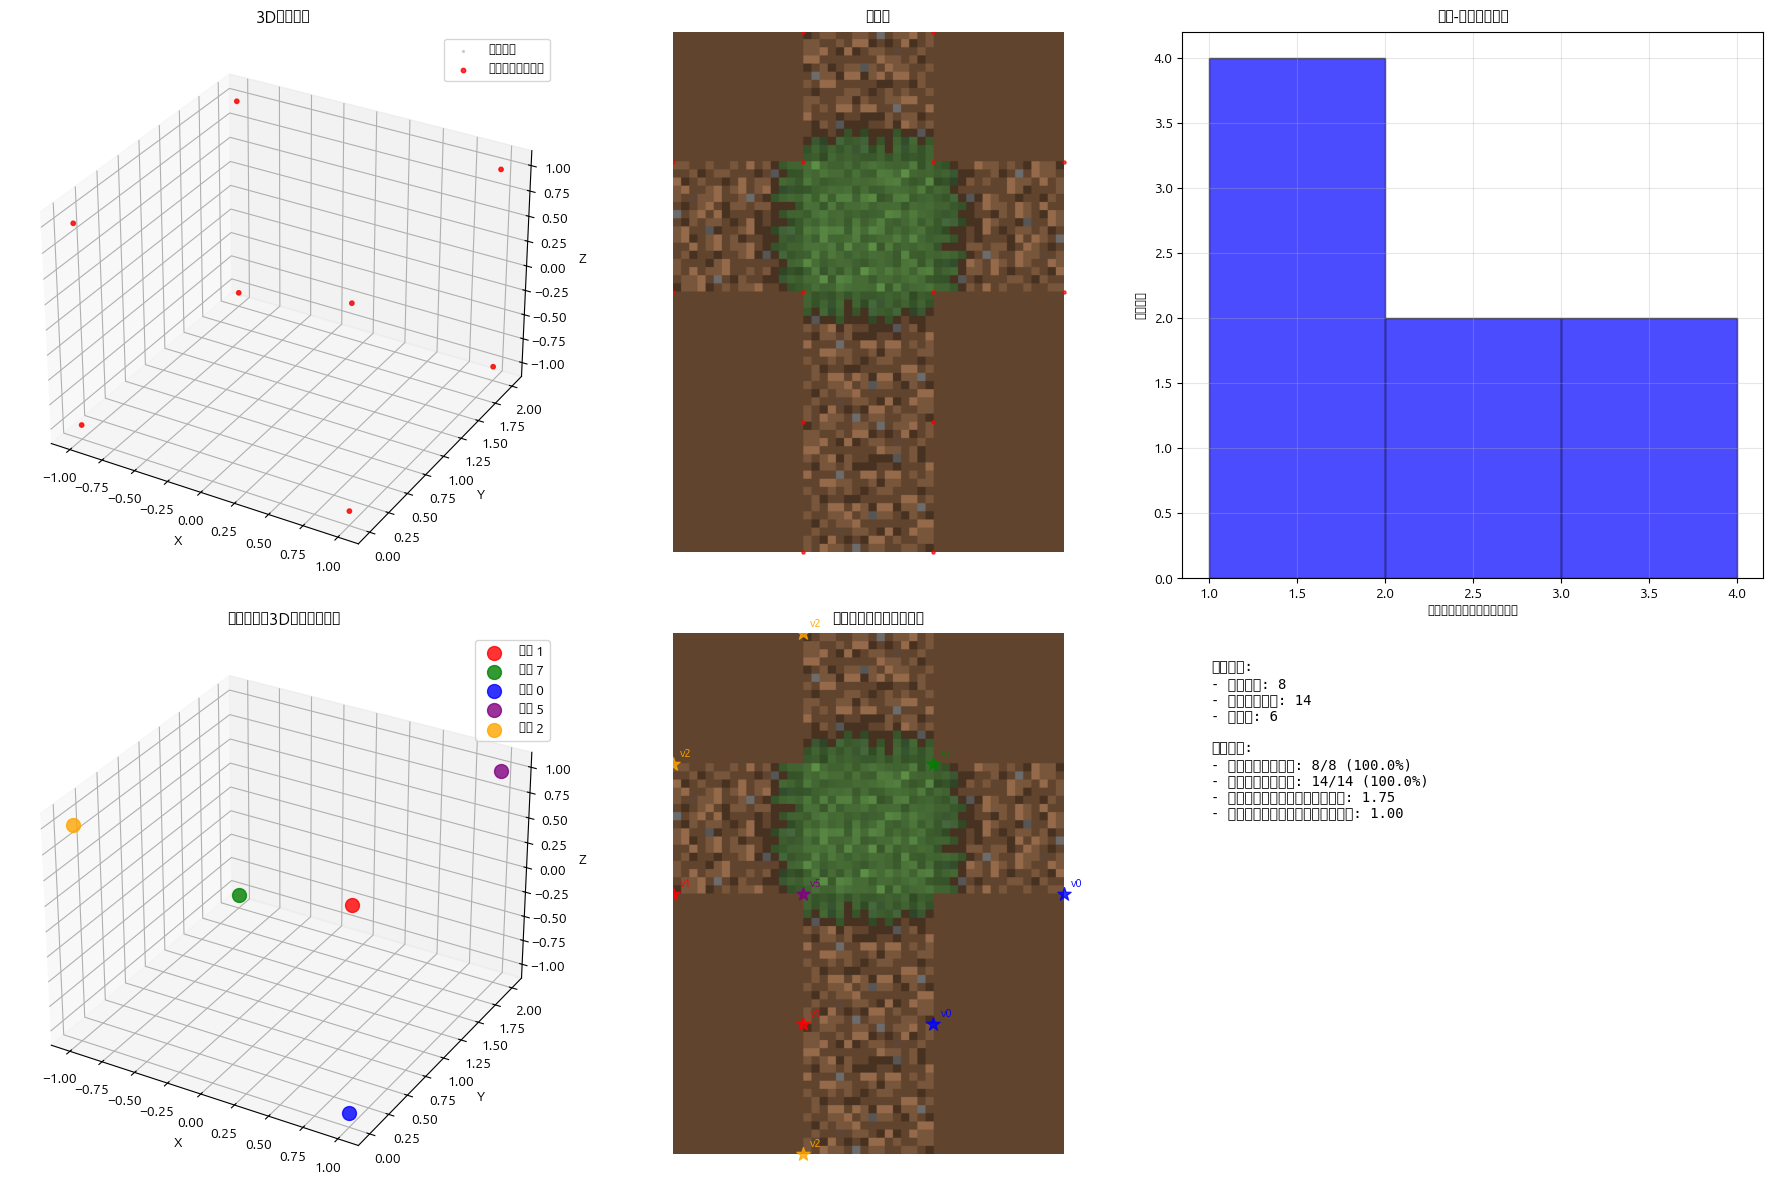

In [60]:
visualize_vertex_texture_mapping(obj_file)